# CISC7204 Assignment 01 — Module 05 / Lab 02: Laptop model evaluation and refinement

**Submitted by:** Xiji Hang (MC646933).

**Laboratory collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131).  
**Collaboration:** All laboratory work is undertaken jointly by both students.

**Data:** [laptop_pricing_dataset_mod2.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv). Each row represents a laptop configuration with price in USD. CPU frequency is the normalized value supplied by the template.
The supplied educational snapshot is loaded independently from `../datasets/raw/laptop_pricing_dataset_mod2.csv`;
it is not assumed to be identical to an earlier laboratory's exported data. Raw data are preserved.

**Evaluation scope:** The initial 10% test example and training-only CV are followed by a 50% development-validation subset repeatedly used for the required degree and alpha demonstrations.

**Local adaptation:** This working copy runs in local Anaconda/Jupyter. Browser-only
installation/download cells are replaced with local imports and data paths. Supplied solution
dropdowns and stale example answers are omitted; the original template remains unchanged.
Numbered questions and their order are retained. IBM template authorship and attribution appear below.

**AI acknowledgement:** [OpenAI Codex](https://openai.com/codex/) was used for coding,
debugging and wording assistance. Numerical results were produced by executing this notebook.

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# **Hands-on Practice Lab: Model Evaluation and Refinement**

Estimated time needed: **45** minutes

In this lab, you will use the skills acquired throughout the module, and try to refine your model's performance in predicting the price of a laptop, given the attribute values.


# Objectives

After completing this lab you will be able to:

 - Use training, testing and cross validation to improve the performance of the dataset. 
 - Identify the point of overfitting of a model
 - Use Ridge Regression to identify the change in performance of a model based on its hyperparameters
 - Use Grid Search to identify the best performing model using different hyperparameters


# Setup


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Local libraries

The local Anaconda environment supplies the required libraries; their versions are printed below.

No browser-only or unpinned package installation is run inside the notebook.

In [1]:
# Figures use 300 DPI for readable high-resolution exports.
from pathlib import Path
import hashlib
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (train_test_split, cross_val_score,
                                    cross_val_predict, GridSearchCV)
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 300,
                     'axes.titlesize': 12, 'axes.labelsize': 11,
                     'legend.fontsize': 9, 'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 8)
pd.set_option('display.precision', 4)
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | '
      f'NumPy {np.__version__} | scikit-learn {sklearn.__version__} | '
      f'seaborn {sns.__version__} | matplotlib {matplotlib.__version__}')

def density_plot(actual, predicted, title):
    fig, ax = plt.subplots()
    sns.kdeplot(x=actual, label='Observed', color='#1c768f', ax=ax)
    sns.kdeplot(x=predicted, label='Fitted', color='#df6b37', ax=ax)
    ax.set(title=title, xlabel='Price (USD)', ylabel='Density (1/USD)')
    ax.legend()
    plt.show()

def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

def metrics_row(label, actual, predicted):
    assert np.isfinite(predicted).all(), 'Predictions must be finite.'
    return {'Model': label, 'R²': r2_score(actual, predicted),
            'MSE (USD²)': mean_squared_error(actual, predicted)}

Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6 | scikit-learn 1.9.0 | seaborn 0.13.2 | matplotlib 3.11.0


### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [2]:
# Imports are grouped in local setup; polynomial, Ridge and cross-validation tools are available.

# Importing the Dataset

Load the independently supplied later-stage laptop snapshot from its preserved local file.

Browser-only download code is replaced with local loading; source provenance is retained.

In [3]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv'

In [4]:
file_name = locate_dataset('laptop_pricing_dataset_mod2.csv')
assert file_name.is_file()
print('Source:',filepath)
print('SHA-256:',hashlib.sha256(file_name.read_bytes()).hexdigest())

Source: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv
SHA-256: 036de9d3f70d59479d86cc9abe1aef75cf96e3ece17524fbefe32cbc910d5316


In [5]:
df = pd.read_csv(file_name, header=0)

Read the existing CSV header. The duplicate browser/headerless-loading branch is not required.

Import the data set into a data frame.


In [6]:
required_features = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']
required_columns = required_features + ['Price']
assert set(required_columns).issubset(df.columns)
assert df[required_columns].notna().all().all()
assert np.isfinite(df[required_columns].to_numpy(dtype=float)).all()
print(f'Rows: {len(df)}; columns: {df.shape[1]}; duplicate rows: {df.duplicated().sum()}')
print('Missing values:', {c: int(n) for c, n in df.isna().sum().items() if n})
print('Required model inputs and target: complete and finite; no rows removed.')

Rows: 238; columns: 16; duplicate rows: 0
Missing values: {}
Required model inputs and target: complete and finite; no rows removed.


Print the value of df.head(). 


In [7]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,...,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,...,978,Low,0,1
1,1,1,Dell,3,...,634,Low,1,0
2,2,2,Dell,3,...,946,Low,1,0
3,3,3,Dell,4,...,1244,Low,0,1
4,4,4,HP,4,...,837,Low,1,0


Drop the two unnecessary columns that have been added into the file, 'Unnamed: 0' and 'Unnamed: 0.1'. Use drop to delete these columns.


In [8]:
export_columns = ['Unnamed: 0','Unnamed: 0.1']
print('Export-index columns present:',[c for c in export_columns if c in df.columns])
assert set(export_columns).issubset(df.columns)
df = df.drop(columns=export_columns)
print('Remaining columns:',df.columns.tolist())

Export-index columns present: ['Unnamed: 0', 'Unnamed: 0.1']
Remaining columns: ['Manufacturer', 'Category', 'GPU', 'OS', 'CPU_core', 'Screen_Size_inch', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_pounds', 'Price', 'Price-binned', 'Screen-Full_HD', 'Screen-IPS_panel']


# Task 1 : Using Cross validation to improve the model

Divide the dataset into x_data and y_data parameters. Here y_data is the "Price" attribute, and x_data has all other attributes in the data set.


In [9]:
y_data = df['Price']
x_data = df.drop(columns='Price')
features = ['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']
assert 'Price-binned' not in features
print('All model fits use CPU_frequency alone or this feature whitelist:',features)

All model fits use CPU_frequency alone or this feature whitelist: ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']


`Price-binned` is derived from the target and is excluded from every model. OS, GPU, Category and CPU_core are retained as supplied codes; their dictionaries are not verified here, so CPU_core is not interpreted as a physical core count. Their numeric distances have no inherent physical meaning. The supplied normalization is treated as part of the fixed educational snapshot.

Split the data set into training and testing subests such that you reserve 10% of the data set for testing purposes.


In [10]:
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=.10,random_state=1)
assert set(x_train.index).isdisjoint(x_test.index)
print(f'Initial split (seed 1): training={len(x_train)}, test={len(x_test)}')

Initial split (seed 1): training=214, test=24


Create a single variable linear regression model using "CPU_frequency" parameter. Print the R^2 value of this model for the training and testing subsets.


In [11]:
lre = LinearRegression().fit(x_train[['CPU_frequency']],y_train)
print(f'Training R²: {lre.score(x_train[["CPU_frequency"]],y_train):.6f}')
print(f'Initial 10% test R²: {lre.score(x_test[["CPU_frequency"]],y_test):.6f}')

Training R²: 0.148298
Initial 10% test R²: -0.065994


Run a 4-fold cross validation on the model and print the mean value of R^2 score along with its standard deviation.


In [12]:
Rcross = cross_val_score(lre,x_train[['CPU_frequency']],y_train,cv=4,scoring='r2')
display(pd.Series(Rcross,index=range(1,5),name='Training-CV fold R²'))
print(f'Mean R²: {Rcross.mean():.6f}; standard deviation: {Rcross.std():.6f}')

1   -0.0066
2    0.2126
3    0.1268
4    0.1768
Name: Training-CV fold R², dtype: float64

Mean R²: 0.127388; standard deviation: 0.083171


In [13]:
print('Cross-validation used only the initial training subset, with the prescribed four unshuffled folds.')
print('The CPU-only model explains little held-out price variation; inspect fold variability as well as the mean.')

Cross-validation used only the initial training subset, with the prescribed four unshuffled folds.
The CPU-only model explains little held-out price variation; inspect fold variability as well as the mean.


# Task 2: Overfitting

Split the data set into training and testing components again, this time reserving 50% of the data set for testing.


In [14]:
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=.50,random_state=0)
assert set(x_train.index).isdisjoint(x_test.index)
print(f'Development split (seed 0): training={len(x_train)}, validation={len(x_test)}')

Development split (seed 0): training=119, validation=119


The 50% excluded subset is repeatedly used to compare degrees and alpha values below. It is therefore development validation; it must not be described as an untouched final test.

To identify the point of overfitting the model on the parameter "CPU_frequency", you'll need to create polynomial features using the single attribute. 
You need to evaluate the R^2 scores of the model created using different degrees of polynomial features, ranging from 1 to 5. Save this set of values of R^2 score as a list.


In [15]:
order = [1,2,3,4,5]
Rsqu_test, degree_train_scores = [], []
for degree in order:
    pr = PolynomialFeatures(degree=degree)
    x_train_pr = pr.fit_transform(x_train[['CPU_frequency']])
    x_test_pr = pr.transform(x_test[['CPU_frequency']])
    lre = LinearRegression().fit(x_train_pr,y_train)
    Rsqu_test.append(lre.score(x_test_pr,y_test))
    degree_train_scores.append(lre.score(x_train_pr,y_train))
print('Validation R² list:',np.round(Rsqu_test,6).tolist())
display(pd.DataFrame({'Degree':order,'Training R²':degree_train_scores,'Validation R²':Rsqu_test}).set_index('Degree'))

Validation R² list: [0.053222, -0.026921, 0.051563, -0.994814, -1.375936]


,Training R²,Validation R²
Degree,,
1,0.1678,0.0532
2,0.3701,-0.0269
3,0.3755,0.0516
4,0.4039,-0.9948
5,0.4173,-1.3759


Plot the values of R^2 scores against the order. Note the point where the score drops.


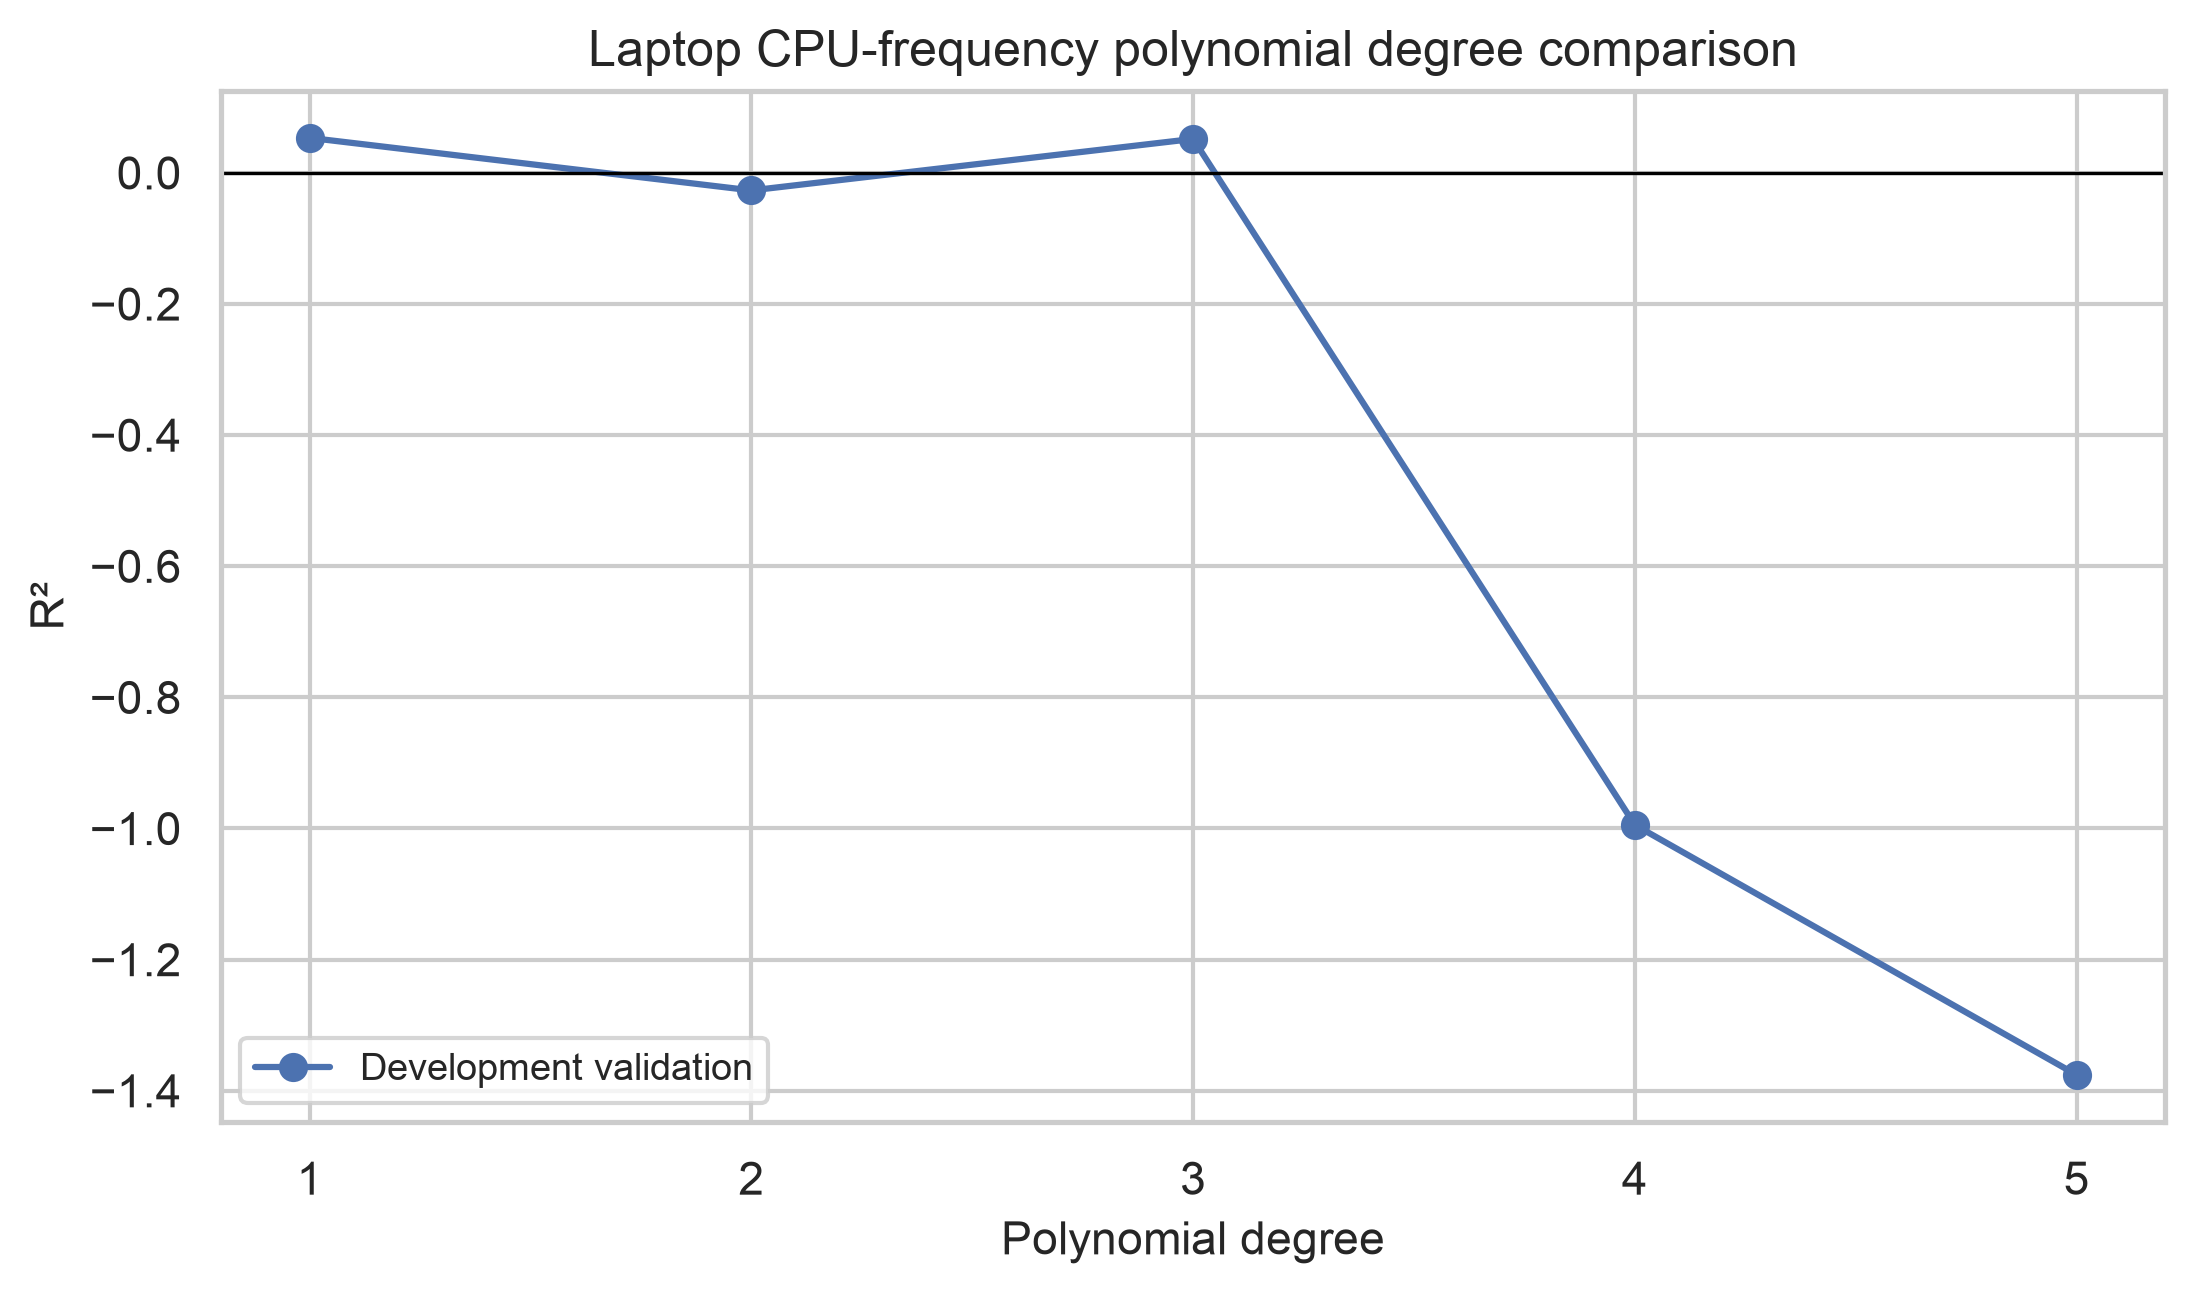

Observed score decreases at: 1→2, 3→4, 4→5
The observed curve is a development diagnostic, not a universal optimal-degree rule.


In [16]:
fig, ax = plt.subplots()
ax.plot(order,Rsqu_test,'o-',label='Development validation')
ax.set(title='Laptop CPU-frequency polynomial degree comparison',xlabel='Polynomial degree',ylabel='R²',xticks=order)
ax.axhline(0,color='black',lw=.8)
ax.legend()
plt.show()
drops = [f'{order[i-1]}→{order[i]}' for i in range(1,len(order)) if Rsqu_test[i]<Rsqu_test[i-1]]
print('Observed score decreases at:',', '.join(drops) if drops else 'none')
print('The observed curve is a development diagnostic, not a universal optimal-degree rule.')

# Task 3 : Ridge Regression

Now consider that you have multiple features, i.e. 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU' and 'Category'. Create a polynomial feature model that uses all these parameters with degree=2. Also create the training and testing attribute sets.


In [17]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train[features])
x_test_pr = pr.transform(x_test[features])
print('Training shape:',x_train_pr.shape,'; validation shape:',x_test_pr.shape)
print('36 columns = constant + 7 first-order + 28 second-order terms.')

Training shape: (119, 36) ; validation shape: (119, 36)
36 columns = constant + 7 first-order + 28 second-order terms.


Create a Ridge Regression model and evaluate it using values of the hyperparameter alpha ranging from 0.001 to 1 with increments of 0.001. 
Create a list of all Ridge Regression R^2 scores for training and testing data. 


In [18]:
from tqdm import tqdm
# Include the stated endpoint 1.000; the example arange stopped at 0.999.
Alpha = np.arange(1,1001,dtype=float)/1000
Rsqu_train, Rsqu_test = [], []
for alpha in tqdm(Alpha,desc='Required 1,000 Ridge settings',mininterval=2):
    RigeModel = Ridge(alpha=alpha,solver='svd').fit(x_train_pr,y_train)
    Rsqu_train.append(RigeModel.score(x_train_pr,y_train))
    Rsqu_test.append(RigeModel.score(x_test_pr,y_test))
ridge_curve = pd.DataFrame({'alpha':Alpha,'Training R²':Rsqu_train,'Validation R²':Rsqu_test})
print(f'Completed {len(Alpha)} settings: {Alpha[0]:.3f} to {Alpha[-1]:.3f}, step 0.001.')
display(ridge_curve.iloc[[0,99,499,998,999]])

Required 1,000 Ridge settings:   0%|          | 0/1000 [00:00<?, ?it/s]

Required 1,000 Ridge settings: 100%|██████████| 1000/1000 [00:01<00:00, 857.53it/s]

Completed 1000 settings: 0.001 to 1.000, step 0.001.


,alpha,Training R²,Validation R²
0,0.001,0.7036,0.3737
99,0.100,0.6763,0.4019
499,0.500,0.6722,0.4163
998,0.999,0.6689,0.4228
999,1.000,0.6689,0.4228


All 1,000 written alpha values are evaluated, including 1.000. The SVD solver is used to handle the unscaled polynomial feature matrix stably; the model objective and required alpha grid are unchanged. No negative R² values are hidden by a fixed 0–1 axis.

Plot the R^2 values for training and testing sets with respect to the value of alpha


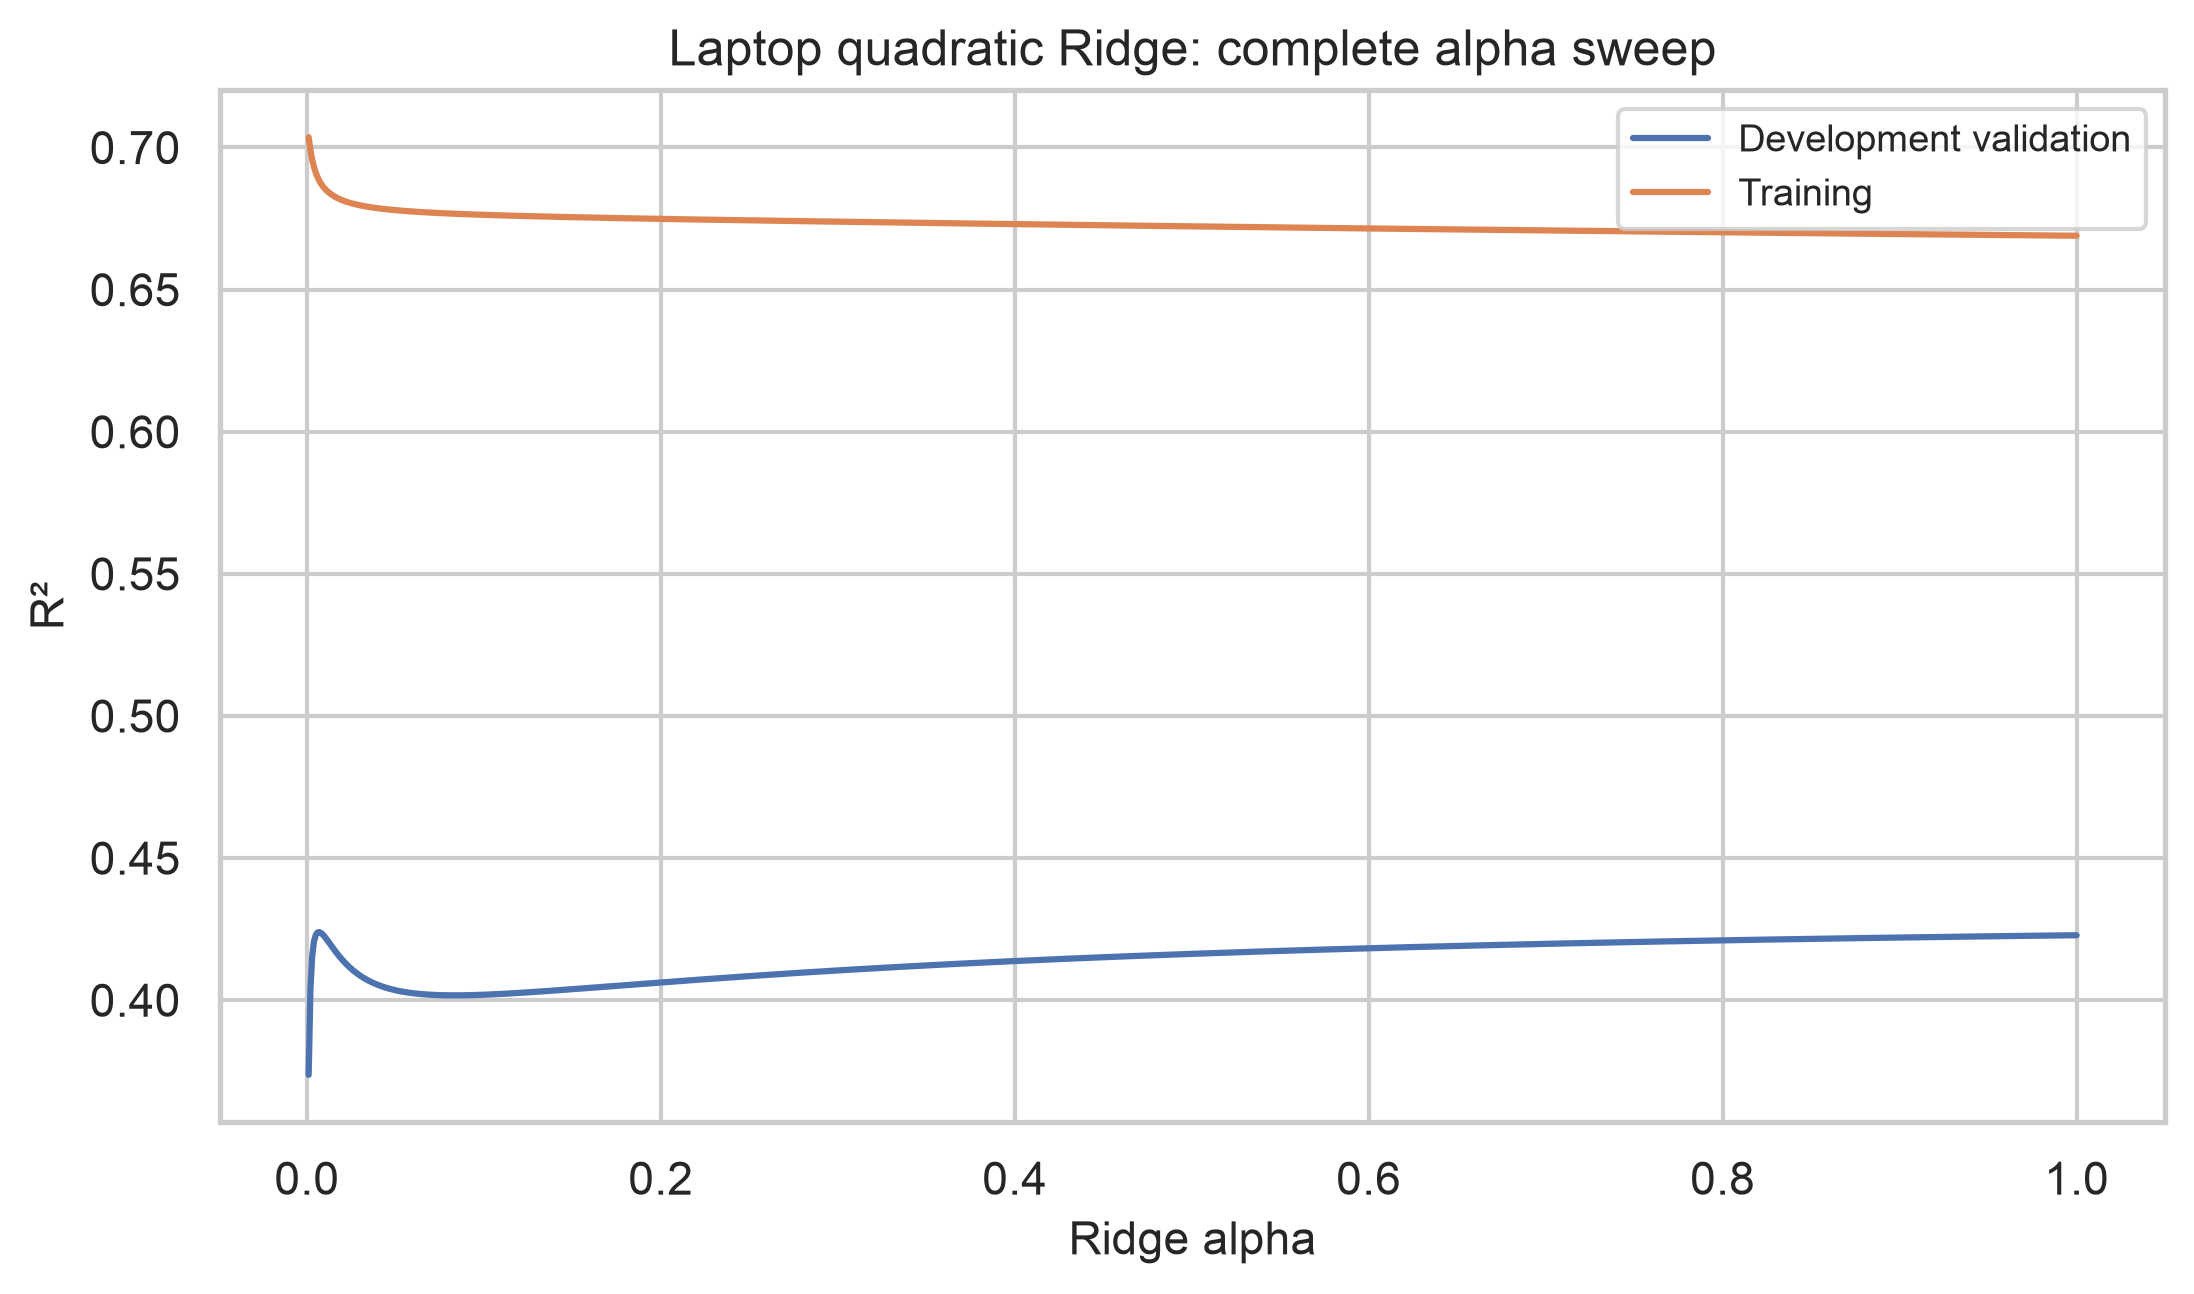

Largest inspected validation R²: 0.423906 at alpha=0.007.


In [19]:
fig, ax = plt.subplots()
ax.plot(Alpha,Rsqu_test,label='Development validation')
ax.plot(Alpha,Rsqu_train,label='Training')
ax.set(title='Laptop quadratic Ridge: complete alpha sweep',xlabel='Ridge alpha',ylabel='R²')
ax.legend()
plt.show()
best_i = int(np.argmax(Rsqu_test))
print(f'Largest inspected validation R²: {Rsqu_test[best_i]:.6f} at alpha={Alpha[best_i]:.3f}.')

# Task 4: Grid Search

Using the raw data and the same set of features as used above, use GridSearchCV to identify the value of alpha for which the model performs best. 
Assume the set of alpha values to be used as
```math
{0.0001, 0.001, 0.01, 0.1, 1, 10}
```


In [20]:
parameters1 = [{'alpha':[0.0001,0.001,0.01,0.1,1,10]}]
print('Raw input features:',features)
print('Grid:',parameters1)

Raw input features: ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']
Grid: [{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}]


Create a Ridge instance and run Grid Search using a 4 fold cross validation.


In [21]:
RR = Ridge(solver='svd')
Grid1 = GridSearchCV(RR,parameters1,cv=4,scoring='r2',error_score='raise')
Grid1

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(solver='svd')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'alpha': [0.0001, 0.001, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_mod

Fit the four-fold grid search using the training data only.

In [22]:
assert set(x_train.index).isdisjoint(x_test.index)
Grid1.fit(x_train[features],y_train)
print(f'Grid fitted to {len(x_train)} training rows and {len(features)} raw features, with four-fold CV.')

Grid fitted to 119 training rows and 7 raw features, with four-fold CV.


Print the R^2 score for the test data using the estimator that uses the derived optimum value of alpha.


In [23]:
BestRR = Grid1.best_estimator_
print('Best alpha:',Grid1.best_params_['alpha'])
print(f'Best training-CV mean R²: {Grid1.best_score_:.6f}')
print(f'Development-validation R²: {BestRR.score(x_test[features],y_test):.6f}')
display(pd.DataFrame(Grid1.cv_results_)[['param_alpha','mean_test_score','std_test_score','rank_test_score']])

Best alpha: 10
Best training-CV mean R²: 0.469577
Development-validation R²: 0.300991


,param_alpha,mean_test_score,std_test_score,rank_test_score
0,0.0001,0.4684,0.2020,6
1,0.0010,0.4684,0.2020,5
2,0.0100,0.4685,0.2019,4
3,0.1000,0.4694,0.2013,2
4,1.0000,0.4687,0.1958,3
5,10.0000,0.4696,0.1485,1


Task 4 searches alpha for the raw seven-feature Ridge model, not the preceding polynomial model. The winning alpha is selected within training CV. Its displayed validation score is useful for this exercise, but repeated earlier access to the same subset prevents a final unbiased-performance claim.

# Congratulations! You have completed the lab


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


Copyright © 2023 IBM Corporation. All rights reserved.


<!--## Change Log


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-16|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-19|0.2|Vicky Kuo|Reviewed and Revised|
--!>
